# Tugas Coding: Clustering dengan K-Means dan Hierarchical Clustering

Notebook ini dirancang agar mahasiswa memahami prinsip clustering, tantangan penentuan jumlah kluster, pengaruh scaling, outlier, fitur berkorelasi, serta evaluasi hasil clustering menggunakan K-Means dan Hierarchical Clustering.

## Tujuan Pembelajaran
Setelah menyelesaikan tugas ini, mahasiswa diharapkan mampu:
1. Menjelaskan prinsip dasar clustering dan perbedaan K-Means dengan hierarchical clustering.
2. Melakukan eksplorasi data sebelum clustering.
3. Menerapkan preprocessing, khususnya standardisasi fitur.
4. Menentukan kandidat jumlah kluster menggunakan Elbow Method, Silhouette Score, dan dendrogram.
5. Membandingkan hasil clustering berdasarkan beberapa konfigurasi model.
6. Menafsirkan karakteristik kluster secara kritis, bukan hanya berdasarkan skor numerik.

## Ketentuan Pengerjaan
- Kerjakan seluruh bagian yang diberi label **Tugas Mahasiswa**.
- Gunakan kode yang tersedia sebagai dasar, tetapi Anda boleh menambahkan visualisasi atau analisis tambahan.
- Semua interpretasi harus ditulis dengan bahasa sendiri dan berbasis bukti dari output notebook.
- Penggunaan AI generatif diperbolehkan sebagai alat bantu, tetapi mahasiswa wajib menuliskan deklarasi penggunaan AI pada bagian akhir notebook.


## 0. Identitas Mahasiswa dan Konfigurasi Pengumpulan

Isi **nama lengkap** dan **NIM** sebelum menjalankan sel berikutnya. Notebook ini menggunakan identitas untuk validasi otomatis,dan pencatatan hasil evaluasi, dan ekspor ringkasan nilai ke Excel/Google Sheet.

In [34]:
# ==========================================================
# IDENTITAS MAHASISWA - WAJIB DIISI
# ==========================================================

NAMA = "Aliya Harta Ary Utama"
NIM = "18223081"
KELAS = "01"  # contoh: 01

# Konfigurasi pengumpulan hasil otomatis
AUTO_EXPORT_EXCEL = True
AUTO_UPLOAD_GOOGLE_SHEET = False  # ubah menjadi True jika dosen menyediakan akses Google Sheet

# Google Sheet configuration - diisi hanya jika AUTO_UPLOAD_GOOGLE_SHEET = True
GOOGLE_SHEET_ID = "ISI_ID_GOOGLE_SHEET"
GOOGLE_WORKSHEET_NAME = "Clustering_Submission"
SERVICE_ACCOUNT_JSON = "service_account.json"  # letakkan file kredensial di direktori kerja notebook

print("Nama :", NAMA)
print("NIM  :", NIM)
print("Kelas:", KELAS)

Nama : Aliya Harta Ary Utama
NIM  : 18223081
Kelas: 01


In [35]:
# ==========================================================
# VALIDASI IDENTITAS MAHASISWA
# ==========================================================
import re
import hashlib
from datetime import datetime

def validate_identity(nama: str, nim: str, kelas: str = ""):
    errors = []
    if not isinstance(nama, str) or nama.strip() == "" or nama.strip() == "ISI_NAMA_LENGKAP":
        errors.append("Nama belum diisi dengan benar.")
    if not isinstance(nim, str) or nim.strip() == "" or nim.strip() == "ISI_NIM":
        errors.append("NIM belum diisi dengan benar.")
    elif not re.fullmatch(r"\d{6,20}", nim.strip()):
        errors.append("NIM harus berupa angka dengan panjang 6-20 digit.")
    if not isinstance(kelas, str) or kelas.strip() == "" or kelas.strip() == "ISI_KELAS":
        errors.append("Kelas belum diisi.")
    return errors

identity_errors = validate_identity(NAMA, NIM, KELAS)
if identity_errors:
    for err in identity_errors:
        print("❌", err)
    raise ValueError("Identitas belum valid. Lengkapi NAMA, NIM, dan KELAS sebelum melanjutkan.")
else:
    STUDENT_FINGERPRINT = hashlib.sha256(f"{NAMA.strip().lower()}|{NIM.strip()}|{KELAS.strip().lower()}".encode()).hexdigest()[:16]
    SUBMISSION_TIMESTAMP = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    print("✅ Identitas valid")
    print("Submission timestamp:", SUBMISSION_TIMESTAMP)
    print("Student fingerprint:", STUDENT_FINGERPRINT)

✅ Identitas valid
Submission timestamp: 2026-05-11 15:08:53
Student fingerprint: b47536db7f079331


## 0.1 Fungsi Auto-Check dan Ekspor Hasil

Sel berikut digunakan untuk mencatat status pengerjaan, menghasilkan file Excel ringkasan, dan mengunggah hasil ke Google Sheet jika konfigurasi dosen tersedia. Mahasiswa cukup menjalankan sel ini tanpa mengubah fungsi.

In [36]:
# ==============================================================
# FUNGSI BANTU AUTO-CHECK, EXCEL EXPORT, DAN GOOGLE SHEET UPLOAD
# ==============================================================
import os
import json
import math
import pandas as pd
from datetime import datetime

AUTOCHECK_RESULTS = {}

def _safe_get(name, default=None):
    return globals().get(name, default)

def record_check(name, passed, detail="", score=0, max_score=1):
    AUTOCHECK_RESULTS[name] = {
        "passed": bool(passed),
        "detail": str(detail),
        "score": float(score),
        "max_score": float(max_score)
    }
    icon = "✅" if passed else "❌"
    print(f"{icon} {name}: {detail}")
    return passed

def export_autocheck_to_excel(filename=None):
    if filename is None:
        filename = f"hasil_autocheck_clustering_{NIM}.xlsx"
    rows = []
    for key, value in AUTOCHECK_RESULTS.items():
        rows.append({
            "Nama": NAMA,
            "NIM": NIM,
            "Kelas": KELAS,
            "Fingerprint": STUDENT_FINGERPRINT,
            "Timestamp": SUBMISSION_TIMESTAMP,
            "Check": key,
            "Passed": value.get("passed", False),
            "Detail": value.get("detail", ""),
            "Score": value.get("score", 0),
            "Max Score": value.get("max_score", 1)
        })
    df = pd.DataFrame(rows)
    summary = pd.DataFrame([{
        "Nama": NAMA,
        "NIM": NIM,
        "Kelas": KELAS,
        "Fingerprint": STUDENT_FINGERPRINT,
        "Timestamp": SUBMISSION_TIMESTAMP,
        "Total Score": df["Score"].sum() if not df.empty else 0,
        "Max Score": df["Max Score"].sum() if not df.empty else 0,
        "Auto Score (%)": round((df["Score"].sum() / df["Max Score"].sum()) * 100, 2) if (not df.empty and df["Max Score"].sum() > 0) else 0
    }])
    with pd.ExcelWriter(filename, engine="openpyxl") as writer:
        summary.to_excel(writer, sheet_name="Summary", index=False)
        df.to_excel(writer, sheet_name="Detail_Check", index=False)
    print(f"✅ Hasil auto-check diekspor ke: {filename}")
    return filename

def upload_autocheck_to_google_sheet():
    """
    Mengunggah ringkasan hasil ke Google Sheet.
    Prasyarat:
    1. Dosen menyediakan GOOGLE_SHEET_ID.
    2. File service_account.json tersedia atau autentikasi Google Colab dikonfigurasi.
    3. Library gspread tersedia: pip install gspread google-auth
    """
    if not AUTO_UPLOAD_GOOGLE_SHEET:
        print("ℹ️ AUTO_UPLOAD_GOOGLE_SHEET = False. Upload Google Sheet dilewati.")
        return False
    if GOOGLE_SHEET_ID == "ISI_ID_GOOGLE_SHEET":
        print("❌ GOOGLE_SHEET_ID belum diisi.")
        return False
    try:
        import gspread
        from google.oauth2.service_account import Credentials
        scopes = ["https://www.googleapis.com/auth/spreadsheets"]
        credentials = Credentials.from_service_account_file(SERVICE_ACCOUNT_JSON, scopes=scopes)
        client = gspread.authorize(credentials)
        spreadsheet = client.open_by_key(GOOGLE_SHEET_ID)
        try:
            worksheet = spreadsheet.worksheet(GOOGLE_WORKSHEET_NAME)
        except Exception:
            worksheet = spreadsheet.add_worksheet(title=GOOGLE_WORKSHEET_NAME, rows=1000, cols=20)
            worksheet.append_row(["Timestamp", "Nama", "NIM", "Kelas", "Fingerprint", "Total Score", "Max Score", "Auto Score (%)"])
        total_score = sum(v.get("score", 0) for v in AUTOCHECK_RESULTS.values())
        max_score = sum(v.get("max_score", 0) for v in AUTOCHECK_RESULTS.values())
        pct = round((total_score / max_score) * 100, 2) if max_score else 0
        worksheet.append_row([SUBMISSION_TIMESTAMP, NAMA, NIM, KELAS, STUDENT_FINGERPRINT, total_score, max_score, pct])
        print("✅ Hasil berhasil diunggah ke Google Sheet.")
        return True
    except Exception as e:
        print("❌ Upload Google Sheet gagal:", str(e))
        print("Pastikan gspread terinstal dan service_account.json memiliki akses editor ke Google Sheet.")
        return False

## 1. Import Library
Jalankan sel berikut untuk memuat seluruh library yang dibutuhkan.

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA

from scipy.cluster.hierarchy import linkage, dendrogram

np.random.seed(42)
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.grid'] = True

## 2. Membuat Dataset Sintetis

Dataset dibuat agar memiliki karakteristik yang realistis dan tidak terlalu mudah dipisahkan:
- sebagian kluster saling tumpang tindih;
- terdapat fitur dengan skala berbeda;
- terdapat outlier ringan;
- beberapa fitur berkorelasi;
- terdapat lebih dari satu jumlah kluster yang tampak masuk akal.

Dataset ini tidak memiliki label kelas asli untuk proses clustering. Label `hidden_group` hanya digunakan dosen untuk memahami struktur data dan tidak boleh digunakan sebagai fitur clustering.

In [38]:
# Membuat data dasar dengan struktur kluster yang tidak terlalu jelas
X_base, hidden_group = make_blobs(
    n_samples=420,
    centers=[[-1.5, 0], [1.2, 0.4], [0.2, 2.2], [4.0, 3.2]],
    cluster_std=[1.1, 1.2, 1.0, 1.4],
    random_state=42
)

# Membuat fitur turunan dengan korelasi dan skala berbeda
f1 = X_base[:, 0]
f2 = X_base[:, 1]
f3 = 2.8 * f1 + np.random.normal(0, 1.0, size=len(f1))          # berkorelasi dengan f1
f4 = 80 + 18 * f2 + np.random.normal(0, 8.0, size=len(f2))       # skala lebih besar
f5 = np.random.normal(0, 1.0, size=len(f1)) + 0.4 * f1           # noise + korelasi ringan

X = np.column_stack([f1, f2, f3, f4, f5])

# Menambahkan outlier ringan
outliers = np.array([
    [6.5, -2.5, 17.0, 35.0, 3.2],
    [-5.5, 4.5, -14.0, 160.0, -2.5],
    [7.2, 6.0, 20.0, 190.0, 1.8],
    [-4.8, -3.5, -13.0, 20.0, -3.0]
])

X_all = np.vstack([X, outliers])
hidden_group_all = np.concatenate([hidden_group, [-1, -1, -1, -1]])

df = pd.DataFrame(X_all, columns=['fitur_1', 'fitur_2', 'fitur_3_korelasi', 'fitur_4_skala_besar', 'fitur_5_noise'])
df['hidden_group'] = hidden_group_all

df.head()

,fitur_1,fitur_2,fitur_3_korelasi,fitur_4_skala_besar,fitur_5_noise,hidden_group
0,0.845376,3.568632,2.863767,160.721351,0.288687,2
1,0.224359,3.123987,0.489940,150.274496,0.764563,3
2,1.237540,1.689984,4.112800,108.427992,-0.627706,2
3,-0.440286,0.454059,0.290228,95.945630,0.206295,0
4,3.103220,-1.085379,8.454863,65.626193,1.407740,1


In [39]:
print('Ukuran dataset:', df.shape)
df.describe().T

Ukuran dataset: (424, 6)


,count,mean,std,min,25%,50%,75%,max
fitur_1,424.0,0.963059,2.383153,-5.500000,-0.818136,0.634218,2.636771,7.602704
fitur_2,424.0,1.452582,1.762011,-3.500000,0.206830,1.294060,2.672414,6.885335
fitur_3_korelasi,424.0,2.717281,6.648451,-14.000000,-2.385151,2.011969,7.247670,22.058076
fitur_4_skala_besar,424.0,105.954794,32.895976,20.000000,82.640557,102.645442,127.978074,204.704994
fitur_5_noise,424.0,0.499671,1.391684,-3.570598,-0.474327,0.503875,1.507141,4.559821
hidden_group,424.0,1.476415,1.140035,-1.000000,0.000000,1.000000,2.000000,3.000000


In [40]:
def deteksi_outlier_iqr(df):
    hasil_outlier = {}
    
    kolom_numerik = df.select_dtypes(include=[np.number]).columns
    
    for kolom in kolom_numerik:
        Q1 = df[kolom].quantile(0.25)
        Q3 = df[kolom].quantile(0.75)
        
        IQR = Q3 - Q1
        
        batas_bawah = Q1 - (1.5 * IQR)
        batas_atas = Q3 + (1.5 * IQR)
        
        kondisi_outlier = (df[kolom] < batas_bawah) | (df[kolom] > batas_atas)
        jumlah_outlier = kondisi_outlier.sum()
        persentase_outlier = (jumlah_outlier / len(df)) * 100
        
        hasil_outlier[kolom] = {
            'Batas Bawah': batas_bawah,
            'Batas Atas': batas_atas,
            'Jumlah Outlier': jumlah_outlier,
            '% Outlier': round(persentase_outlier, 2)
        }
        
    df_ringkasan = pd.DataFrame(hasil_outlier).T
    return df_ringkasan

ringkasan_outlier = deteksi_outlier_iqr(df)

print("Ringkasan Deteksi Outlier (Metode IQR):")
display(ringkasan_outlier)

Ringkasan Deteksi Outlier (Metode IQR):


,Batas Bawah,Batas Atas,Jumlah Outlier,% Outlier
fitur_1,-6.000497,7.819132,0.0,0.00
fitur_2,-3.491547,6.370791,2.0,0.47
fitur_3_korelasi,-16.834382,21.696901,1.0,0.24
fitur_4_skala_besar,14.634280,195.984351,1.0,0.24
fitur_5_noise,-3.446530,4.479344,2.0,0.47
hidden_group,-3.000000,5.000000,0.0,0.00


## 3. Eksplorasi Data Awal

Sebelum menjalankan clustering, amati distribusi fitur, skala data, korelasi antarfitur, dan indikasi outlier.

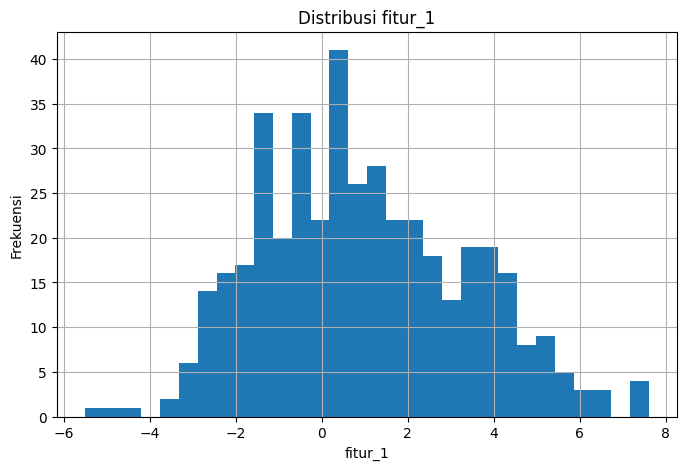

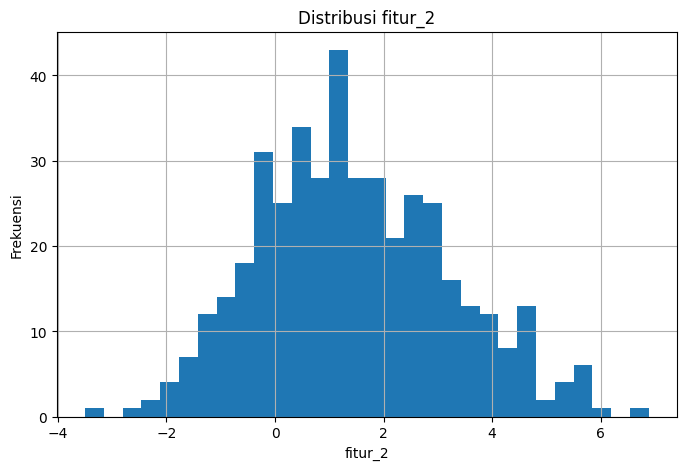

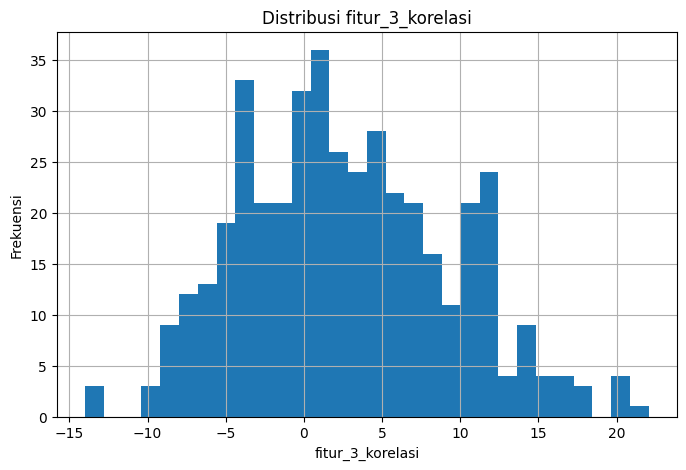

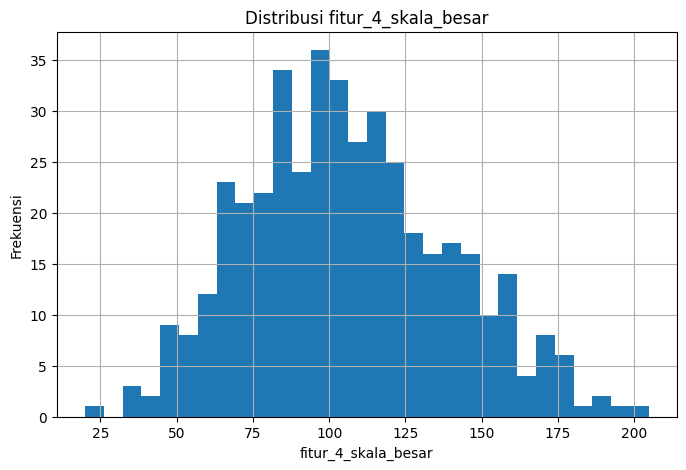

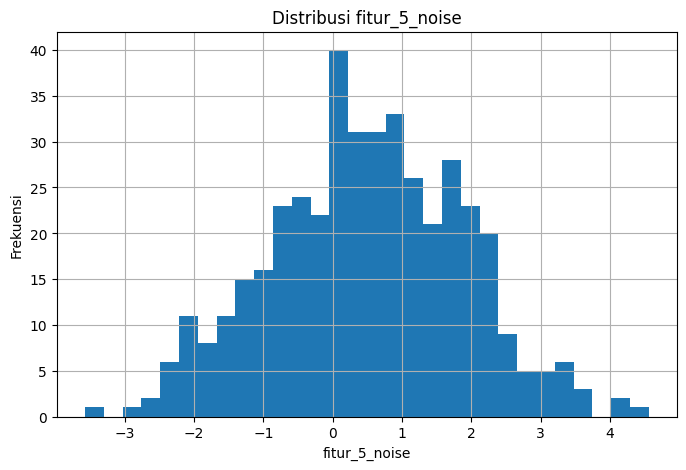

In [41]:
# Visualisasi distribusi setiap fitur
feature_cols = ['fitur_1', 'fitur_2', 'fitur_3_korelasi', 'fitur_4_skala_besar', 'fitur_5_noise']

for col in feature_cols:
    plt.figure()
    plt.hist(df[col], bins=30)
    plt.title(f'Distribusi {col}')
    plt.xlabel(col)
    plt.ylabel('Frekuensi')
    plt.show()

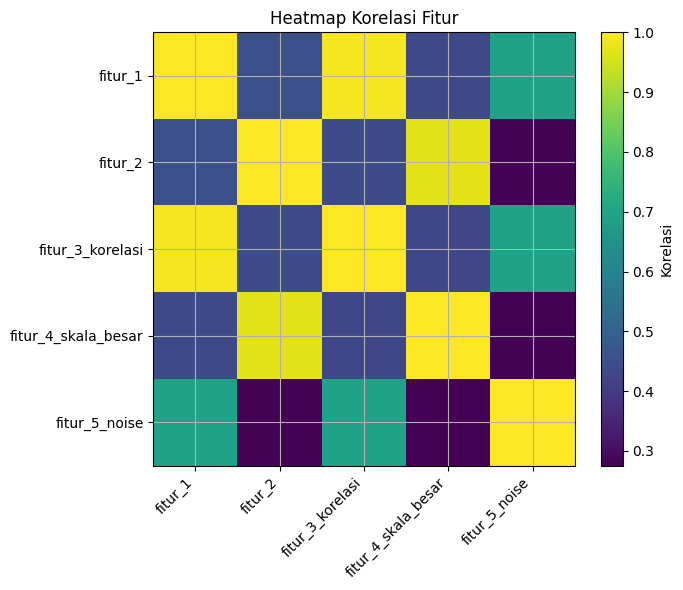

,fitur_1,fitur_2,fitur_3_korelasi,fitur_4_skala_besar,fitur_5_noise
fitur_1,1.000000,0.451836,0.989702,0.436332,0.693802
fitur_2,0.451836,1.000000,0.444686,0.969963,0.279302
fitur_3_korelasi,0.989702,0.444686,1.000000,0.429155,0.691686
fitur_4_skala_besar,0.436332,0.969963,0.429155,1.000000,0.275142
fitur_5_noise,0.693802,0.279302,0.691686,0.275142,1.000000


In [42]:
# Korelasi antar fitur
corr = df[feature_cols].corr()
plt.figure(figsize=(7, 6))
plt.imshow(corr, aspect='auto')
plt.colorbar(label='Korelasi')
plt.xticks(range(len(feature_cols)), feature_cols, rotation=45, ha='right')
plt.yticks(range(len(feature_cols)), feature_cols)
plt.title('Heatmap Korelasi Fitur')
plt.tight_layout()
plt.show()

corr

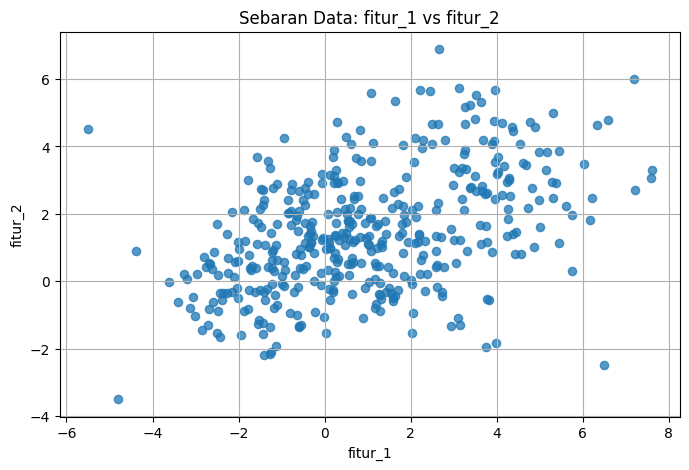

In [43]:
# Visualisasi dua fitur awal untuk melihat struktur kasar data
plt.figure()
plt.scatter(df['fitur_1'], df['fitur_2'], s=35, alpha=0.75)
plt.title('Sebaran Data: fitur_1 vs fitur_2')
plt.xlabel('fitur_1')
plt.ylabel('fitur_2')
plt.show()

### Tugas Mahasiswa 1 — Analisis Eksplorasi Data
Jawab pertanyaan berikut:
1. Fitur mana yang memiliki skala paling berbeda dibanding fitur lainnya? Mengapa hal ini penting untuk clustering?
2. Fitur mana yang tampak berkorelasi kuat? Apa dampaknya terhadap interpretasi kluster?
3. Apakah terdapat indikasi outlier? Jelaskan berdasarkan visualisasi atau statistik deskriptif.
4. Berdasarkan scatter plot awal, apakah jumlah kluster terlihat jelas? Jelaskan.

Berdasarkan hasil pada EDA : 
1. Jika dilihat berdasarkan nilai skala yang dimiliki oleh masing-masing fitur, fitur_4_skala_besar memiliki skala yang paling berbeda daripada fitur lainnya. fitur_4_skala_besar memiliki rentang nilai dari 20 hingga 204, standar deviasi sekitar 32.9, dan mean 105.9, dimana fitur lainnya memiliki standar deviasi diantara 1 - 6 dan mean 0 - 3. Dimana nilai fitur_4_skala_besar memiliki gap yang sangat besar. Fitur ini harus diclustering karena beberapa algoritma clustering sangat sensitif terhadap skala karena menggunakan perhitungan jarak. Jika data tidak distandardisasi terlebih dahulu, fitur berskala besar seperti fitur_4_skala_besar akan mendominasi perhitungan jarak secara matematis. Oleh karena itu, diperlukan clustering agar hasil tidak bias dan akurat.  

2. Berdasarkan heatmap korelasi fitur, fitur_1 dan fitur_3_korelasi dengan nilai korelasi: 0.989 serta fitur_2 dan fitur_4_skala_besar memiliki nilai korelasi: 0.969 menunjukkan korelasi positif yang sangat kuat yang mendekati 1.0. Dampaknya terhadap interprestasi kluster adalah hal ini mengindikasikan adanya multikolinearitas, yang berarti fitur-fitur tersebut merepresentasikan informasi yang redundan atau tumpang tindih.  

3. Terdapat indikasi outlier yang diperlihatkan oleh metrik statistik maupun visual. Berdasarkan tabel ringkasan deteksi outlier menggunakan metode Interquartile Range (IQR), terdapat beberapa outlier yang terdeteksi fitur_2, fitur_3_korelasi, fitur_4_skala_besar, fitur_5_noise, dimana hal ini didukung pada visualisasi yang memperlihatkan terdapat nilai yang muncul di tail.  

4. Berdasarkan hasil visualisasi scatter plot di awal, belum menunjukkan cluster yang jelas, karena sebaran data terlihat memusat tanpa pemisah yang jelas antar kelompok. Dibutuhkan pemrosesan lebih lanjut untuk menentukan cluster.

## 4. Preprocessing: Standardisasi Fitur

K-Means dan hierarchical clustering berbasis jarak sangat sensitif terhadap skala fitur. Oleh karena itu, data perlu distandardisasi.

In [44]:
X_raw = df[feature_cols].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

scaled_df = pd.DataFrame(X_scaled, columns=feature_cols)
scaled_df.describe().T

,count,mean,std,min,25%,50%,75%,max
fitur_1,424.0,1.256856e-17,1.001181,-2.715182,-0.748294,-0.138149,0.703140,2.789367
fitur_2,424.0,-1.047380e-16,1.001181,-2.814076,-0.707841,-0.090073,0.693113,3.086911
fitur_3_korelasi,424.0,-2.094760e-17,1.001181,-2.517433,-0.768368,-0.106212,0.682225,2.912505
fitur_4_skala_besar,424.0,-4.357102e-16,1.001181,-2.616014,-0.709563,-0.100719,0.670273,3.005439
fitur_5_noise,424.0,8.379042e-18,1.001181,-2.928162,-0.700696,0.003024,0.724777,2.920883


Explained variance ratio: [0.65767898 0.25760445]


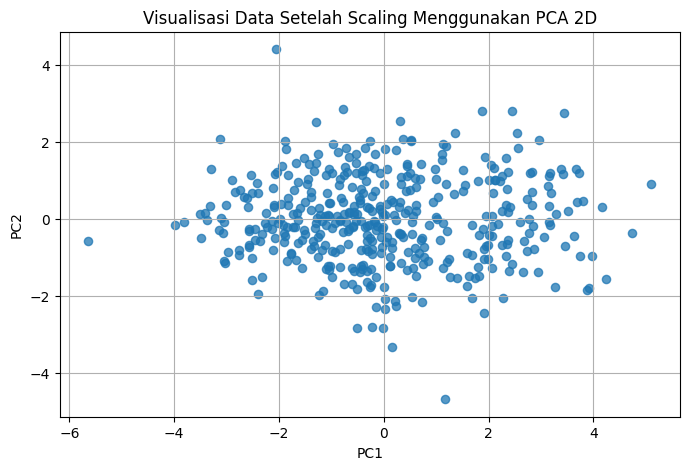

In [45]:
# Visualisasi PCA 2D setelah scaling untuk membantu analisis struktur data
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])

print('Explained variance ratio:', pca.explained_variance_ratio_)

plt.figure()
plt.scatter(pca_df['PC1'], pca_df['PC2'], s=35, alpha=0.75)
plt.title('Visualisasi Data Setelah Scaling Menggunakan PCA 2D')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

## 5. K-Means: Menentukan Jumlah Kluster

Gunakan beberapa metrik untuk mengevaluasi jumlah kluster. Perhatikan bahwa tidak selalu ada satu jawaban benar. Mahasiswa harus memberikan argumentasi berbasis bukti.

In [46]:
k_values = range(2, 11)
inertias = []
silhouette_scores = []
db_scores = []
ch_scores = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))
    db_scores.append(davies_bouldin_score(X_scaled, labels))
    ch_scores.append(calinski_harabasz_score(X_scaled, labels))

eval_kmeans = pd.DataFrame({
    'k': list(k_values),
    'inertia': inertias,
    'silhouette': silhouette_scores,
    'davies_bouldin': db_scores,
    'calinski_harabasz': ch_scores
})

eval_kmeans

,k,inertia,silhouette,davies_bouldin,calinski_harabasz
0,2,1196.168893,0.378004,1.014946,325.921138
1,3,924.348714,0.285673,1.227793,272.283168
2,4,715.867063,0.307394,1.024268,274.602117
3,5,625.529161,0.285194,1.100113,250.261427
4,6,559.256963,0.271945,1.151718,233.306202
5,7,505.869540,0.249955,1.153285,221.760865
6,8,464.069917,0.251844,1.142025,212.057614
7,9,432.662021,0.244293,1.139138,202.307236
8,10,405.320999,0.239845,1.169566,194.599426


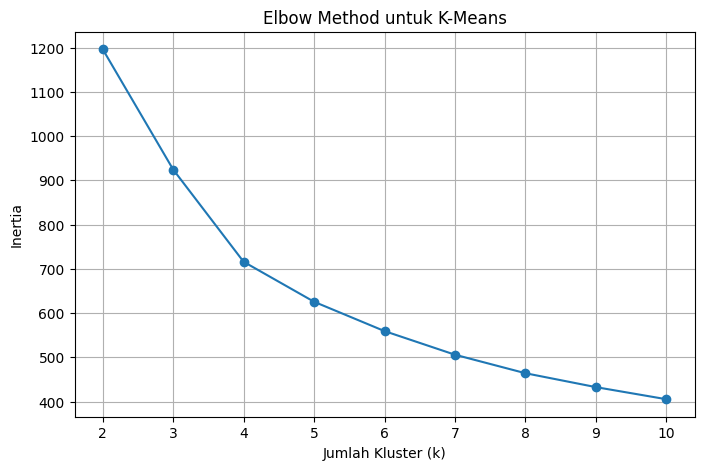

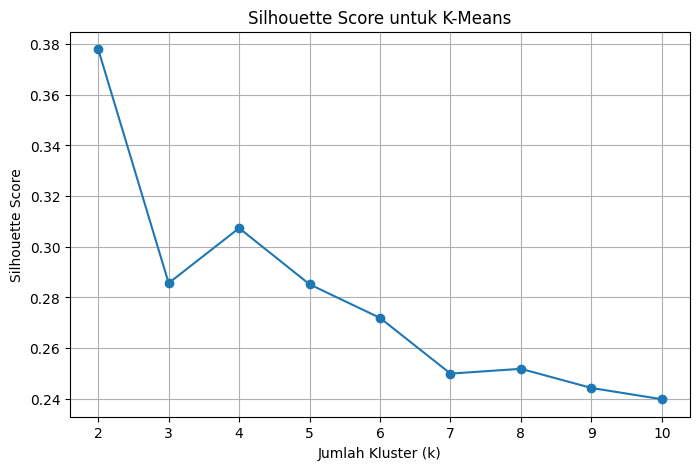

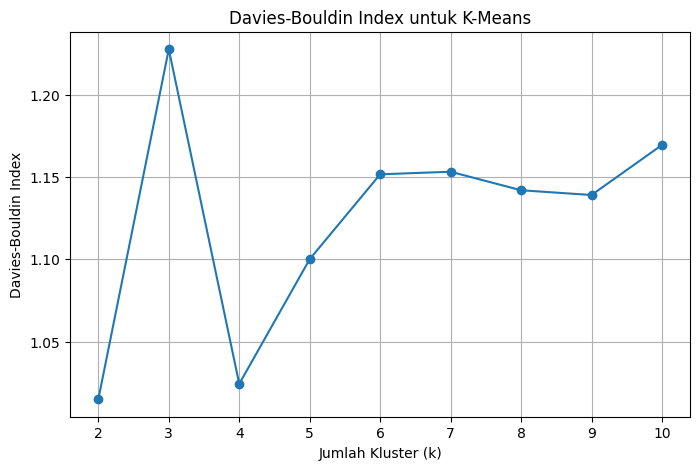

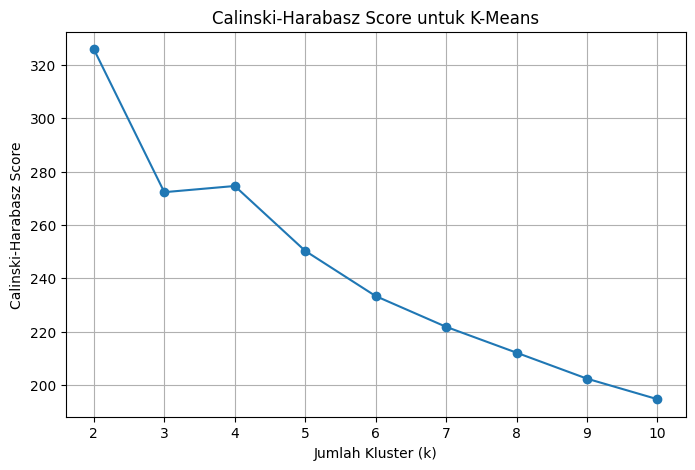

In [47]:
plt.figure()
plt.plot(eval_kmeans['k'], eval_kmeans['inertia'], marker='o')
plt.title('Elbow Method untuk K-Means')
plt.xlabel('Jumlah Kluster (k)')
plt.ylabel('Inertia')
plt.show()

plt.figure()
plt.plot(eval_kmeans['k'], eval_kmeans['silhouette'], marker='o')
plt.title('Silhouette Score untuk K-Means')
plt.xlabel('Jumlah Kluster (k)')
plt.ylabel('Silhouette Score')
plt.show()

plt.figure()
plt.plot(eval_kmeans['k'], eval_kmeans['davies_bouldin'], marker='o')
plt.title('Davies-Bouldin Index untuk K-Means')
plt.xlabel('Jumlah Kluster (k)')
plt.ylabel('Davies-Bouldin Index')
plt.show()

plt.figure()
plt.plot(eval_kmeans['k'], eval_kmeans['calinski_harabasz'], marker='o')
plt.title('Calinski-Harabasz Score untuk K-Means')
plt.xlabel('Jumlah Kluster (k)')
plt.ylabel('Calinski-Harabasz Score')
plt.show()

### Tugas Mahasiswa 2 — Pemilihan Jumlah Kluster K-Means
Jawab pertanyaan berikut:
1. Berdasarkan Elbow Method, berapa kandidat jumlah kluster yang masuk akal?
2. Berdasarkan Silhouette Score, jumlah kluster mana yang tampak paling baik?
3. Apakah semua metrik memberikan rekomendasi jumlah kluster yang sama? Jika tidak, bagaimana Anda mengambil keputusan?
4. Pilih satu nilai `k` utama dan satu nilai `k` pembanding. Jelaskan alasan pemilihan tersebut.

1. Berdasarkan Elbow Method, jika terlihat di visualisasi, penurunan nilai k yang mulai melandai dimana penurunan nilai inertia sudah tidak terlalu drastis yaitu pada k=3 atau k=4. 
2. Berdasarkan Silhouette Score, nilai tertinggi didapatkan pada k = 2 dengan nilai 0.38, dimana nilai Silhouette Score mengukur seberapa dekat setiap titik dalam satu kluster dengan titik-titik di kluster tetangganya. Namun, terdapat juga local optimum yang cukup menonjol pada k=4 yaitu sekitar 0.307. Sebelum, score terus menurun untuk nilai k yang lebih besar. 
3. Seluruh cluster menghasilkan variansi nilai yang cukup berbeda, pada Silhouette Score dan Calinski-Harabasz menghailkan k=2 sebagai nilai optimum, sedangkan Elbow Method memberikan rekomendasi nilai k = 3 atau k = 4. Sehingga, tidak bisa diambil keputusan hanya berdasarkan hasil nilai terbaik, namun terdapat analisis lebih lanjut. Seperti, kita bisa melakukan pemilihan nilai k pembanding selain berdasarkan mencari kesepakatan antar metrik dan mempertimbangkan kebutuhan interpretasi domain masalah. 
4. Pilihan k utama adalah k = 4, meskipun bukan yang tertinggi, k = 4 adalah titik kompromi terbaik dari seluruh metrik. Nilai ini merupakan titik siku pada Elbow Method, sekaligus membentuk local maximum pada grafik Silhouette dan Calinski-Harabasz, serta local minimum pada Davies-Bouldin Index. Alasan kenapa tidak k = 2 yang dijadikan model utama karena, jika hanya dibagi menjadi 2 kelompok menjadi kurang informatif dan kurang actionable. Selanjutnya k = 3 dipilih sebagai model alternatif karena k = 3 merupakan titik patahan pertama yang sangat tajam pada grafik inertia.

## 6. K-Means: Pelatihan Model dan Visualisasi Hasil

Ubah nilai `k_utama` dan `k_pembanding` sesuai hasil analisis Anda.

In [48]:
# Silakan ubah berdasarkan hasil analisis Anda
k_utama = 4
k_pembanding = 3

kmeans_utama = KMeans(n_clusters=k_utama, random_state=42, n_init=20)
kmeans_pembanding = KMeans(n_clusters=k_pembanding, random_state=42, n_init=20)

df['cluster_kmeans_utama'] = kmeans_utama.fit_predict(X_scaled)
df['cluster_kmeans_pembanding'] = kmeans_pembanding.fit_predict(X_scaled)

print('Distribusi cluster K-Means utama:')
print(df['cluster_kmeans_utama'].value_counts().sort_index())

print('Distribusi cluster K-Means pembanding:')
print(df['cluster_kmeans_pembanding'].value_counts().sort_index())

Distribusi cluster K-Means utama:
cluster_kmeans_utama
0    114
1     93
2    106
3    111
Name: count, dtype: int64
Distribusi cluster K-Means pembanding:
cluster_kmeans_pembanding
0    186
1    106
2    132
Name: count, dtype: int64


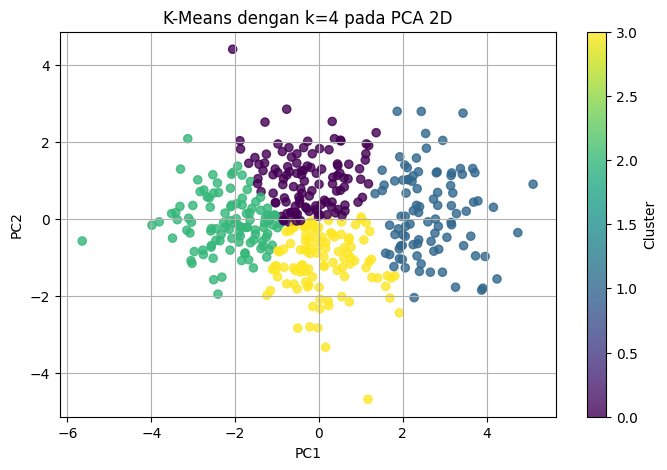

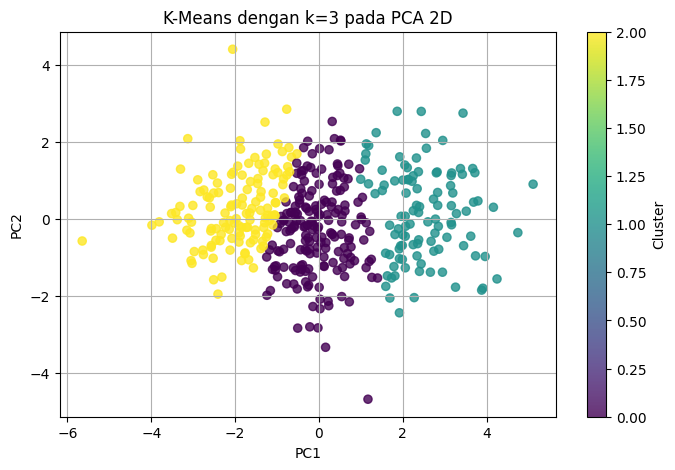

In [49]:
def plot_cluster_pca(labels, title):
    plt.figure()
    scatter = plt.scatter(pca_df['PC1'], pca_df['PC2'], c=labels, s=35, alpha=0.8)
    plt.title(title)
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.colorbar(scatter, label='Cluster')
    plt.show()

plot_cluster_pca(df['cluster_kmeans_utama'], f'K-Means dengan k={k_utama} pada PCA 2D')
plot_cluster_pca(df['cluster_kmeans_pembanding'], f'K-Means dengan k={k_pembanding} pada PCA 2D')

In [50]:
# Profil kluster berdasarkan rata-rata fitur asli
profile_kmeans = df.groupby('cluster_kmeans_utama')[feature_cols].mean()
profile_kmeans

,fitur_1,fitur_2,fitur_3_korelasi,fitur_4_skala_besar,fitur_5_noise
cluster_kmeans_utama,,,,,
0,-0.043322,2.244294,-0.065013,121.301877,-0.290548
1,4.040444,3.576001,11.178499,144.665449,1.824796
2,-1.572852,-0.207040,-4.366428,75.139135,-0.562575
3,1.839970,0.445257,5.250266,87.187240,1.215403


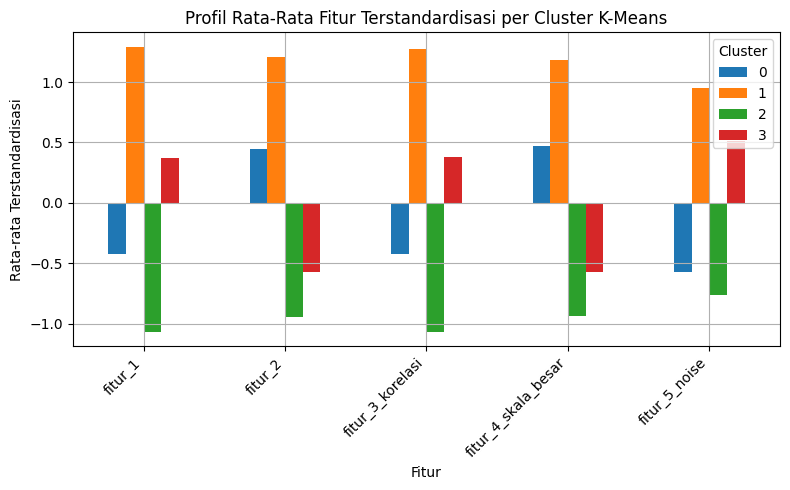

In [51]:
# Visualisasi profil kluster dalam data yang sudah distandardisasi
profile_scaled = pd.DataFrame(X_scaled, columns=feature_cols)
profile_scaled['cluster'] = df['cluster_kmeans_utama']
profile_scaled_mean = profile_scaled.groupby('cluster')[feature_cols].mean()

profile_scaled_mean.T.plot(kind='bar')
plt.title('Profil Rata-Rata Fitur Terstandardisasi per Cluster K-Means')
plt.xlabel('Fitur')
plt.ylabel('Rata-rata Terstandardisasi')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

### Tugas Mahasiswa 3 — Interpretasi K-Means
Jawab pertanyaan berikut:
1. Jelaskan karakteristik setiap kluster berdasarkan profil fitur.
2. Apakah ada kluster yang sangat kecil atau tampak didominasi outlier? Jelaskan.
3. Bandingkan hasil `k_utama` dan `k_pembanding`. Mana yang lebih mudah dijelaskan secara substantif?
4. Mengapa visualisasi PCA 2D tidak boleh menjadi satu-satunya dasar penentuan kualitas kluster?

Berdasarkan hasil diatas:
1. Berdasarkan hasil visualisasi Profil Rata-Rata Fitur Terstandardisasi dan tabel untuk k = 4, Cluster 1 (orange) : memiliki nilai paling tinggi secara ekstrem di semua fitur dibandingkan cluster lainnya, Cluster 2 (hijau) : memiliki rata-rata paling rendah untuk seluruh fitur yang ditandai dengan bernilai negatif tebal pada skala standar, Cluster 0 (biru) : memiliki nilai di atas rata-rata pada fitur_2 dan fitur_4_skala_besar, namun memiliki nilai di bawah rata-rata pada fitur_1, fitur_3_korelasi, dan fitur_5_noise, Cluster 4 (merah) : memiliki nilai yang tinggi pada fitur_1, fitur_3_korelasi, dan fitur_5_noise, namun memiliki nilai di bawah rata-rata pada fitur_2 dan fitur_4_skala_besar, sehingga cluster ini adalah kebalikan dari Cluster 0. 
2. Berdasarkan hasil persebaran data, proporsi tiap cluster seimbang, dimana Cluster 0: 114 data (26.8%), Cluster 1: 93 data (21.9%), Cluster 2: 106 data (25.0%), Cluster 3: 111 data (26.1%). Sehingga tidak ada cluster yang sangat kecil datanya. 
3. Berdasarkan hasil visualisasi diatas, hasil dengan k = 4 lebih mudah dijelaskan karena setiap kluster menunjukkan profil yang lebih unik dan berbeda satu sama lain. Pada k = 3, salah satu klusternya menjadi sangat besar dan menggabungkan dua kelompok yang sebenarnya berbeda (yang dipecah pada k = 4), sehingga interpretasinya menjadi kurang spesifik.
4. Visualisasi PCA 2D hanya menangkap sebagian dari total varians data. Mengandalkannya saja bisa menyesatkan, karena struktur pemisahan cluster yang penting mungkin ada pada dimensi (PC) lain yang tidak divisualisasikan.



## 7. Hierarchical Clustering: Dendrogram

Dendrogram membantu melihat struktur penggabungan data. Karena dendrogram dengan seluruh data dapat terlalu padat, visualisasi berikut menggunakan sampel data.

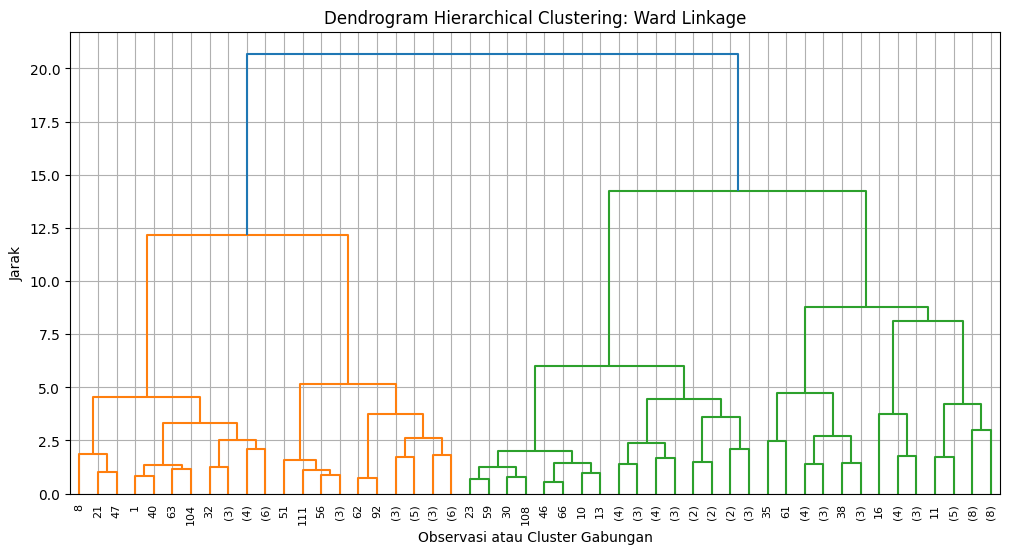

In [52]:
# Ambil sampel agar dendrogram terbaca
sample_size = 120
sample_idx = np.random.choice(np.arange(X_scaled.shape[0]), size=sample_size, replace=False)
X_sample = X_scaled[sample_idx]

Z_ward = linkage(X_sample, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(Z_ward, truncate_mode='level', p=5)
plt.title('Dendrogram Hierarchical Clustering: Ward Linkage')
plt.xlabel('Observasi atau Cluster Gabungan')
plt.ylabel('Jarak')
plt.show()

### Tugas Mahasiswa 4 — Analisis Dendrogram
Jawab pertanyaan berikut:
1. Berdasarkan dendrogram, berapa kandidat jumlah kluster yang masuk akal?
2. Apakah hasil dendrogram mendukung hasil K-Means? Jelaskan.
3. Apa keterbatasan penggunaan dendrogram pada dataset berukuran besar atau memiliki outlier?

1. Berdasarkan dendrogram, jumlah kandidat kluster yang paling masuk akal adalah 2, 3, atau 4 kluster. Hal ini terlihat dari jarak vertikal yang panjang sebelum garis horizontal berikutnya muncul, yang menandakan bahwa penggabungan tersebut menyatukan kelompok-kelompok yang relatif jauh.
2. Hasil dendrogram mendukung analisis K-Means sebelumnya. Baik dendrogram maupun metrik K-Means terutama pada Elbow Method sama-sama merekomendasikan k ke 3 atau 4 sebagai jumlah cluster yang paling potensial, menandakan adanya struktur yang konsisten dalam data. Serta, dendrogram menunjukkan bahwa penggabungan terakhir memiliki jarak lompatan yang paling jauh/tinggi. Dimana hal ini mengkonfirmasi mengapa metrik matematis seperti Silhouette Score memuncak di k = 2, karena secara hierarki, pemisahan dua gumpalan besar ini adalah yang paling solid.
3. Dendrogram memiliki keterbatasan dalam menghadapi dataset besar dimana dendrogram menjadi sangat padat dan tidak mungkin untuk diinterpretasikan secara visual karena terlalu banyak data point, keterbatasan selanjutnya adalah dalam menghadapi outlier, dimana outlier sering kali muncul sebagai cluster tersendiri atau digabungkan paling akhir dengan jarak yang sangat jauh, yang dapat mengganggu skala visual dendrogram dan menyulitkan identifikasi struktur kluster utama.

## 8. Hierarchical Clustering: Perbandingan Linkage

Bandingkan beberapa metode linkage untuk melihat pengaruh strategi penggabungan kluster.

In [53]:
linkage_methods = ['ward', 'complete', 'average', 'single']
n_clusters_h = 4

hier_results = []

for method in linkage_methods:
    model = AgglomerativeClustering(n_clusters=n_clusters_h, linkage=method)
    labels = model.fit_predict(X_scaled)
    hier_results.append({
        'linkage': method,
        'n_clusters': n_clusters_h,
        'silhouette': silhouette_score(X_scaled, labels),
        'davies_bouldin': davies_bouldin_score(X_scaled, labels),
        'calinski_harabasz': calinski_harabasz_score(X_scaled, labels)
    })
    df[f'cluster_hier_{method}'] = labels

hier_eval = pd.DataFrame(hier_results)
hier_eval

,linkage,n_clusters,silhouette,davies_bouldin,calinski_harabasz
0,ward,4,0.283423,1.070530,240.486602
1,complete,4,0.180811,1.151531,155.967577
2,average,4,0.337587,0.614026,106.128888
3,single,4,0.289182,0.395041,5.508532


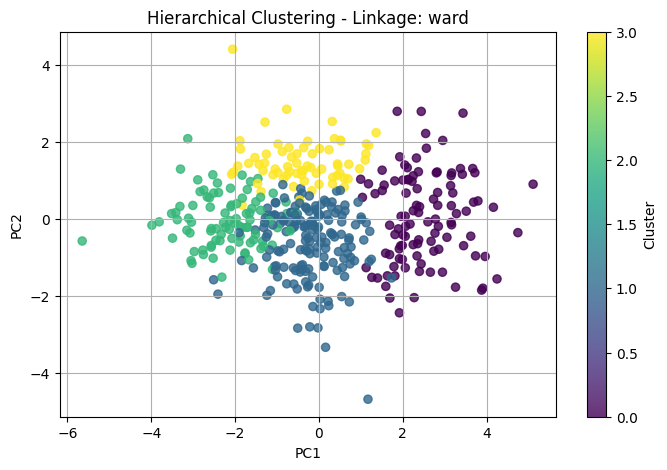

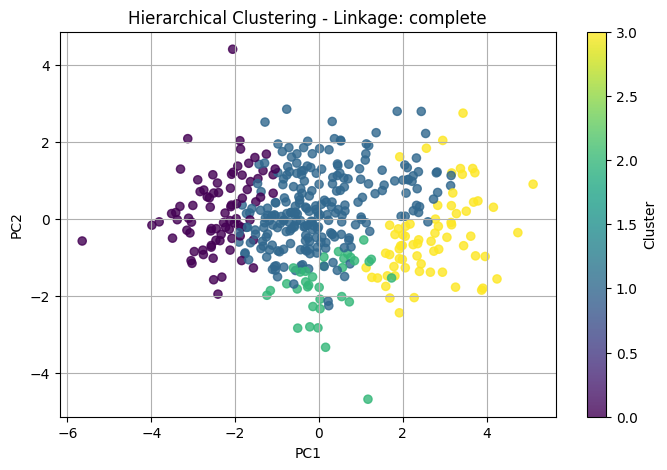

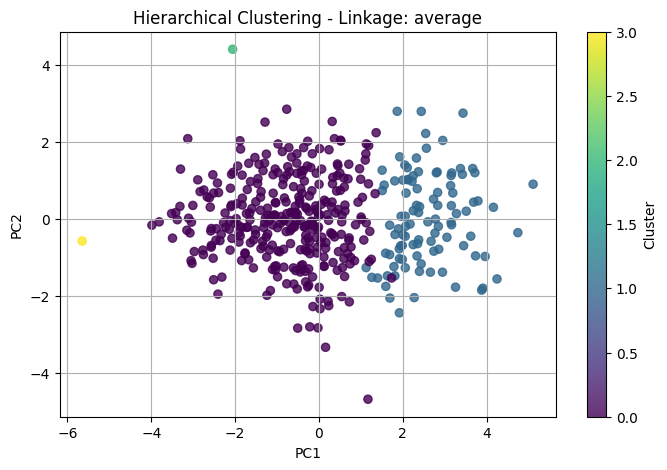

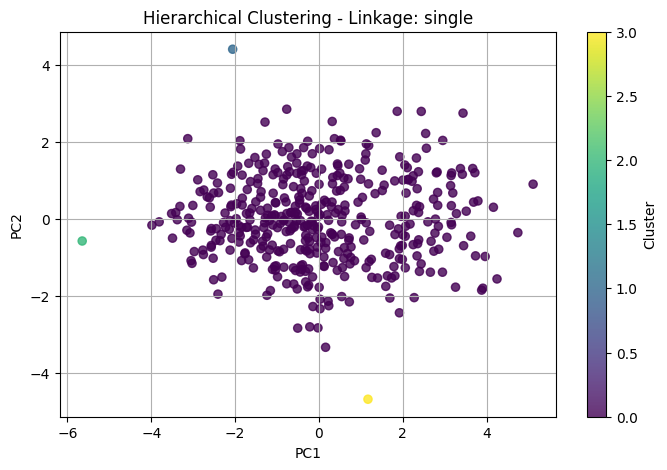

In [54]:
for method in linkage_methods:
    plot_cluster_pca(df[f'cluster_hier_{method}'], f'Hierarchical Clustering - Linkage: {method}')

In [55]:
# Profil hierarchical clustering dengan linkage Ward
profile_hier_ward = df.groupby('cluster_hier_ward')[feature_cols].mean()
profile_hier_ward

,fitur_1,fitur_2,fitur_3_korelasi,fitur_4_skala_besar,fitur_5_noise
cluster_hier_ward,,,,,
0,4.016275,3.355791,11.137602,140.430007,1.769392
1,1.185499,0.662684,3.469493,91.279430,0.695050
2,-1.794052,-0.189585,-5.021793,75.438801,-0.487255
3,-0.587379,2.597066,-1.710003,128.578709,-0.601494


### Tugas Mahasiswa 5 — Analisis Hierarchical Clustering
Jawab pertanyaan berikut:
1. Linkage mana yang memberikan hasil paling baik berdasarkan metrik evaluasi? Jelaskan.
2. Apakah linkage dengan skor terbaik juga menghasilkan visualisasi dan profil kluster yang paling mudah ditafsirkan?
3. Apa risiko menggunakan `single linkage` pada data dengan outlier atau data yang saling berdekatan?
4. Bandingkan hasil hierarchical clustering terbaik dengan K-Means utama.

1. Berdasarkan metrik hasil evaluasi, pada metrik Silhouette Score linkage average memiliki skor tertinggi (0.337), disusul single (0.289) dan ward (0.283). Selanjutnya pada Davies-Bouldin Index linkage single memiliki skor terendah/terbaik (0.395), disusul average (0.614). Selanjutnya untuk metrik Calinski-Harabasz, ward menang telak dengan skor 240.48. Berdasarkan hasil ketiga metrik dapat disimpulkan ward memberikan hasil paling baik. Metode ini secara konsisten menghasilkan skor Silhouette dan Calinski-Harabasz tinggi serta skor Davies-Bouldin rendah, yang semuanya mengindikasikan struktur kluster yang lebih padat dan terpisah dengan baik.
2. Meskipun average dan single linkage memiliki skor Silhouette yang lebih tinggi dan Davies-Bouldin yang lebih rendah, visualisasi PCA-nya menunjukkan bahwa mereka gagal melakukan segmentasi yang bermakna. Namun, ward linkage, meskipun skor Silhouette-nya sedikit lebih rendah, menghasilkan segmentasi data yang paling rasional, seimbang, dan mudah ditafsirkan.
3. Risiko utama menggunakan single linkage adalah efek berantai. Metode ini cenderung menggabungkan kluster-kluster yang berdekatan hanya karena satu titik dari masing-masing kluster saling berdekatan. Hal ini membuatnya sangat sensitif terhadap noise dan outlier, sering kali menghasilkan satu kluster besar yang memanjang dan beberapa kluster kecil yang berisi outlier, seperti yang terlihat pada visualisasi PCA. 
4. Hasil hierarchical clustering dengan linkage ward sangat mirip dengan hasil K-Means utama (k=4). Keduanya mengidentifikasi struktur kluster yang sama, memiliki skor evaluasi yang hampir identik, dan menghasilkan profil kluster yang sebanding. Hal inini memberikan keyakinan bahwa struktur 4-kluster yang ditemukan cukup stabil dan bukan hasil acak dari satu algoritma saja.

## 9. Perbandingan Akhir Model

Bandingkan model berdasarkan evaluasi numerik, visualisasi, distribusi ukuran kluster, dan kemudahan interpretasi.

In [56]:
comparison = []

# K-Means utama
labels = df['cluster_kmeans_utama']
comparison.append({
    'model': f'KMeans_k{k_utama}',
    'silhouette': silhouette_score(X_scaled, labels),
    'davies_bouldin': davies_bouldin_score(X_scaled, labels),
    'calinski_harabasz': calinski_harabasz_score(X_scaled, labels),
    'cluster_size': dict(pd.Series(labels).value_counts().sort_index())
})

# K-Means pembanding
labels = df['cluster_kmeans_pembanding']
comparison.append({
    'model': f'KMeans_k{k_pembanding}',
    'silhouette': silhouette_score(X_scaled, labels),
    'davies_bouldin': davies_bouldin_score(X_scaled, labels),
    'calinski_harabasz': calinski_harabasz_score(X_scaled, labels),
    'cluster_size': dict(pd.Series(labels).value_counts().sort_index())
})

# Hierarchical methods
for method in linkage_methods:
    labels = df[f'cluster_hier_{method}']
    comparison.append({
        'model': f'Hierarchical_{method}_k{n_clusters_h}',
        'silhouette': silhouette_score(X_scaled, labels),
        'davies_bouldin': davies_bouldin_score(X_scaled, labels),
        'calinski_harabasz': calinski_harabasz_score(X_scaled, labels),
        'cluster_size': dict(pd.Series(labels).value_counts().sort_index())
    })

comparison_df = pd.DataFrame(comparison)
comparison_df

,model,silhouette,davies_bouldin,calinski_harabasz,cluster_size
0,KMeans_k4,0.307394,1.024268,274.602117,"{0: 114, 1: 93, 2: 106, 3: 111}"
1,KMeans_k3,0.285673,1.227793,272.283168,"{0: 186, 1: 106, 2: 132}"
2,Hierarchical_ward_k4,0.283423,1.070530,240.486602,"{0: 104, 1: 162, 2: 90, 3: 68}"
3,Hierarchical_complete_k4,0.180811,1.151531,155.967577,"{0: 82, 1: 239, 2: 34, 3: 69}"
4,Hierarchical_average_k4,0.337587,0.614026,106.128888,"{0: 322, 1: 100, 2: 1, 3: 1}"
5,Hierarchical_single_k4,0.289182,0.395041,5.508532,"{0: 421, 1: 1, 2: 1, 3: 1}"


### Tugas Mahasiswa 6 — Kesimpulan Akhir
Tuliskan kesimpulan akhir dalam 3–5 paragraf yang mencakup:
1. Model dan jumlah kluster yang Anda pilih sebagai solusi utama.
2. Alasan pemilihan berdasarkan metrik evaluasi, visualisasi, dan interpretasi profil kluster.
3. Tantangan utama yang muncul dalam proses clustering pada dataset ini.
4. Keterbatasan analisis Anda.
5. Rekomendasi analisis lanjutan jika dataset ini berasal dari kasus nyata, misalnya segmentasi pelanggan, segmentasi wilayah, atau segmentasi risiko.


Sebagai solusi utama, model K-Means dengan empat kluster (k=4) dipilih karena dinilai paling mampu merepresentasikan struktur data secara keseluruhan. Keputusan ini tidak hanya didasarkan pada satu indikator, melainkan hasil pertimbangan dari beberapa pendekatan evaluasi. Berdasarkan Elbow Method, nilai k=4 menunjukkan titik “siku” yang cukup jelas, yaitu saat penambahan jumlah kluster tidak lagi memberikan penurunan inersia yang berarti. Walaupun Silhouette Score mencapai nilai tertinggi pada k=2, penggunaan empat kluster dianggap lebih optimal karena memberikan keseimbangan antara hasil evaluasi numerik dan kemudahan dalam interpretasi. Selain itu, hasil ini juga diperkuat melalui Hierarchical Clustering dengan metode linkage ward yang menghasilkan pola kluster yang hampir sama, sehingga menunjukkan bahwa struktur empat kluster cukup stabil dan memang mencerminkan karakteristik data.  

Selama proses analisis, tantangan utama yang dihadapi adalah menentukan jumlah kluster yang paling tepat. Hal ini disebabkan oleh perbedaan hasil yang diberikan oleh berbagai metrik evaluasi, sehingga keputusan akhir tidak bisa semata-mata bergantung pada nilai tertinggi dari satu metrik saja. Diperlukan pertimbangan tambahan berupa interpretasi terhadap profil kluster yang dihasilkan. Di samping itu, adanya perbedaan skala antar fitur, korelasi yang cukup tinggi, serta keberadaan outlier menjadi faktor penting yang harus diperhatikan. Oleh karena itu, tahap preprocessing seperti standardisasi menjadi langkah krusial untuk memastikan bahwa tidak ada fitur tertentu yang mendominasi hasil clustering.  

Analisis ini juga memiliki beberapa keterbatasan. Pertama, data yang digunakan merupakan data sintetis, sehingga hasil interpretasi kluster hanya bersifat statistik dan tidak dapat langsung dikaitkan dengan konteks bisnis atau domain tertentu. Kedua, metode yang digunakan terbatas pada K-Means dan Hierarchical Clustering, sehingga belum mencakup algoritma lain seperti DBSCAN yang berpotensi memberikan sudut pandang berbeda, terutama dalam menangani outlier. Ketiga, proses validasi kluster hanya dilakukan secara internal menggunakan metrik evaluasi dan visualisasi, tanpa adanya validasi eksternal seperti data berlabel atau masukan dari ahli domain.  

Apabila analisis ini diterapkan pada kasus nyata, misalnya segmentasi pelanggan, langkah lanjutan yang disarankan adalah memperkaya karakteristik setiap kluster dengan informasi tambahan seperti data demografis maupun data transaksi. Hal ini bertujuan agar setiap segmen dapat diberi identitas yang lebih jelas, misalnya “pelanggan loyal bernilai tinggi” atau “pelanggan baru dengan risiko churn”. Selain itu, analisis lanjutan seperti Market Basket Analysis dapat dilakukan pada masing-masing segmen untuk mengidentifikasi pola pembelian yang spesifik. Dengan demikian, hasil segmentasi dapat dimanfaatkan untuk menyusun strategi pemasaran yang lebih terarah, seperti pemberian promosi khusus atau program retensi yang disesuaikan dengan karakteristik tiap segmen.

## 10. Pertanyaan Reflektif Konseptual
Jawab secara ringkas tetapi argumentatif.

1. Mengapa clustering tidak dapat dievaluasi dengan akurasi seperti supervised learning?
2. Mengapa nilai silhouette yang tinggi belum tentu menjamin kluster bermakna secara bisnis atau domain?
3. Dalam kondisi apa K-Means kurang sesuai digunakan?
4. Dalam kondisi apa hierarchical clustering lebih informatif dibanding K-Means?
5. Jelaskan mengapa preprocessing dapat mengubah hasil clustering secara signifikan.


1. Clustering termasuk unsupervised learning yang tidak memiliki label ground truth sebagai acuan. Akurasi membutuhkan perbandingan antara prediksi dan label sebenarnya, sedangkan dalam clustering, kebenaran struktur data tidak diketahui sejak awal. Oleh karena itu, evaluasi lebih mengandalkan metrik internal seperti cohesion dan separation atau validasi eksternal jika label tersedia.  
2. Silhouette score hanya mengukur seberapa kompak dan terpisah cluster secara matematis, bukan relevansi atau maknanya. Cluster yang terlihat rapi secara statistik belum tentu mencerminkan segmentasi yang berguna atau dapat ditindaklanjuti dalam konteks bisnis, karena tidak mempertimbangkan variabel domain, interpretasi manusia, atau tujuan analisis.  
3. K-Means kurang cocok ketika data memiliki bentuk cluster yang tidak bulat, terdapat banyak outlier, distribusi cluster tidak seimbang, atau skala fitur sangat berbeda. Selain itu, K-Means juga bermasalah jika jumlah cluster (k) tidak diketahui dengan jelas atau data memiliki hubungan non-linear yang kompleks.  
4. Hierarchical clustering lebih informatif ketika ingin memahami struktur hubungan antar data secara bertingkat / hierarki, bukan hanya pembagian akhir. Metode ini juga berguna ketika jumlah kluster belum diketahui, karena dendrogram dapat membantu menentukan jumlah kluster secara visual, serta lebih fleksibel dalam menangani berbagai bentuk kluster.   
5. Preprocessing, seperti standardisasi atau normalisasi, mempengaruhi cara algoritma menghitung jarak antar data. Tanpa preprocessing, fitur dengan skala besar dapat mendominasi perhitungan jarak dan menghasilkan kluster yang bias. Selain itu, penanganan outlier dan korelasi fitur juga dapat mengubah struktur distribusi data, sehingga berdampak langsung pada hasil akhir clustering.  


## 11. Deklarasi Penggunaan AI
Isi bagian berikut sesuai penggunaan Anda.

**Apakah Anda menggunakan AI generatif dalam pengerjaan tugas ini?** Ya/Tidak  

Jika ya, jelaskan:
1. Tool AI yang digunakan.
2. Bagian yang dibantu oleh AI.
3. Prompt utama yang digunakan.
4. Bagian yang Anda verifikasi atau perbaiki secara mandiri.
5. Pernyataan bahwa seluruh analisis akhir telah Anda pahami dan validasi sendiri.

Tuliskan deklarasi Anda di bawah ini.


Ya, saya menggunakan AI

- Tool AI yang digunakan: Gemini, ChatGPT. 

- Bagian yang dibantu oleh AI: AI generatif digunakan sebagai asisten untuk memperdalam pemahaman konsep dan teori yang relevan dengan tugas clustering ini. Bantuan AI tidak digunakan untuk melakukan analisis data atau menulis interpretasi hasil secara langsung. Fokus penggunaan AI adalah untuk mendapatkan penjelasan lebih rinci mengenai:    
1. Prinsip dasar K-Means dan Hierarchical Clustering.  
2. Pentingnya standardisasi fitur dan dampaknya pada algoritma berbasis jarak.  
3. Interpretasi metrik evaluasi kluster seperti Inertia (Elbow Method), Silhouette Score, Davies-Bouldin Index, dan Calinski-Harabasz Score.  
4. Konsep berbagai metode linkage (Ward, complete, average, single) dalam Hierarchical Clustering.  
5. Dampak dari adanya outlier dan fitur berkorelasi tinggi terhadap hasil clustering.  
6. Fungsi dan keterbatasan Principal Component Analysis (PCA) sebagai teknik visualisasi.  

- Prompt utama yang digunakan:

1. "Jelaskan perbedaan antara K-Means dan Hierarchical Clustering."  
2. "Bagaimana cara menginterpretasikan Silhouette Score dalam clustering?"  
3. "Apa itu metode linkage 'ward' dan bagaimana bedanya dengan 'single linkage'?"  

- Bagian yang Anda verifikasi atau perbaiki secara mandiri: Seluruh proses analisis, mulai dari eksplorasi data, preprocessing, eksekusi model, evaluasi metrik, hingga penulisan interpretasi dan kesimpulan akhir, dilakukan sepenuhnya secara mandiri. Penjelasan konseptual dari AI digunakan sebagai dasar pengetahuan, namun penerapannya pada konteks dataset ini divalidasi dan dianalisis sendiri.

- Pernyataan: Dengan ini saya menyatakan bahwa seluruh analisis, kode, dan kesimpulan dalam notebook ini adalah hasil kerja saya sendiri. AI generatif hanya digunakan sebagai alat bantu untuk pemahaman konseptual, dan saya bertanggung jawab penuh atas kebenaran serta validitas seluruh hasil analisis yang disajikan.